In [5]:
%run /Users/2923185/Desktop/'New NextMGT'/Codes/'T100 MGT - Steady State'/'Functions_3 - Solver.ipynb'
%run /Users/2923185/Desktop/'New NextMGT'/'Experimental Data'/'Phase 2'/Subroutines/"Experimental Data Post Process Functions.ipynb"
%run /Users/2923185/Desktop/'New NextMGT'/Codes/'T100 MGT - Steady State'/'Functions_3 - Solver.ipynb'
%run /Users/2923185/Desktop/'New NextMGT'/'Secondements'/PSI/Codes/Subroutines/'Preprocess Experimental Data'/'Experimental Data Post Process Functions_PSI Data.ipynb'


2023-05-25 09:02:23.496820: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
name = 'Data Preparation for Week 1'

main_path = os.path.join('/Users/2923185/Desktop/New NextMGT/Offshore Microgrid', 'Models/' + name )
# path_training_history = main_path + '/Training History'
# path_trained_model_and_scaler = main_path + '/Trained Model'
# path_saving_figure = '/Users/2923185/Desktop/New NextMGT/Offshore Microgrid/Figures/' + name


In [7]:
# Load data
data_path = '/Users/2923185/Desktop/New NextMGT/Offshore Microgrid/Data/Weather Data/weather data - week 1.csv'
data = pd.read_csv(data_path)
data_reserve = data.copy()


In [8]:
df = pd.DataFrame({})
df['T_amb [degC]'] = data['air_temperature_2m'] - 273.15
df['p_amb [bar]'] = data['air_pressure_at_sea_level']/100000
df['S_w [m/s]'] = data['wind_speed_10m']
df['D_w [deg]'] = data['wind_direction_10m']



In [9]:
scaler = joblib.load('/Users/2923185/Desktop/New NextMGT/Conceptual Microgrid/Models/Wind Turbine - ANN - 4 Inputs - filtered - SI units/Trained Model/model1_scaler.save') 
model = keras.models.load_model('/Users/2923185/Desktop/New NextMGT/Conceptual Microgrid/Models/Wind Turbine - ANN - 4 Inputs - filtered - SI units/Trained Model/model1.h5')


In [10]:
input_parameters = ['S_w [m/s]','D_w [deg]','T_amb [degC]','p_amb [bar]']
output_parameters = ['P_WT [kW]']


Y = nn_function3(model,df[['S_w [m/s]','D_w [deg]','T_amb [degC]','p_amb [bar]']],scaler=scaler)
df[output_parameters] = Y




df['P_WT [MW]'] = 8*4* df['P_WT [kW]']/1000
df = df[input_parameters+['P_WT [MW]']]
df = df[input_parameters+['P_WT [MW]']]
# scaling_factor = 8/df['P_WT [MW]'].max()
# print('scaling factor:',scaling_factor)
# if scaling_factor<1:
#     df['P_WT [MW]'] = scaling_factor*df['P_WT [MW]'] 




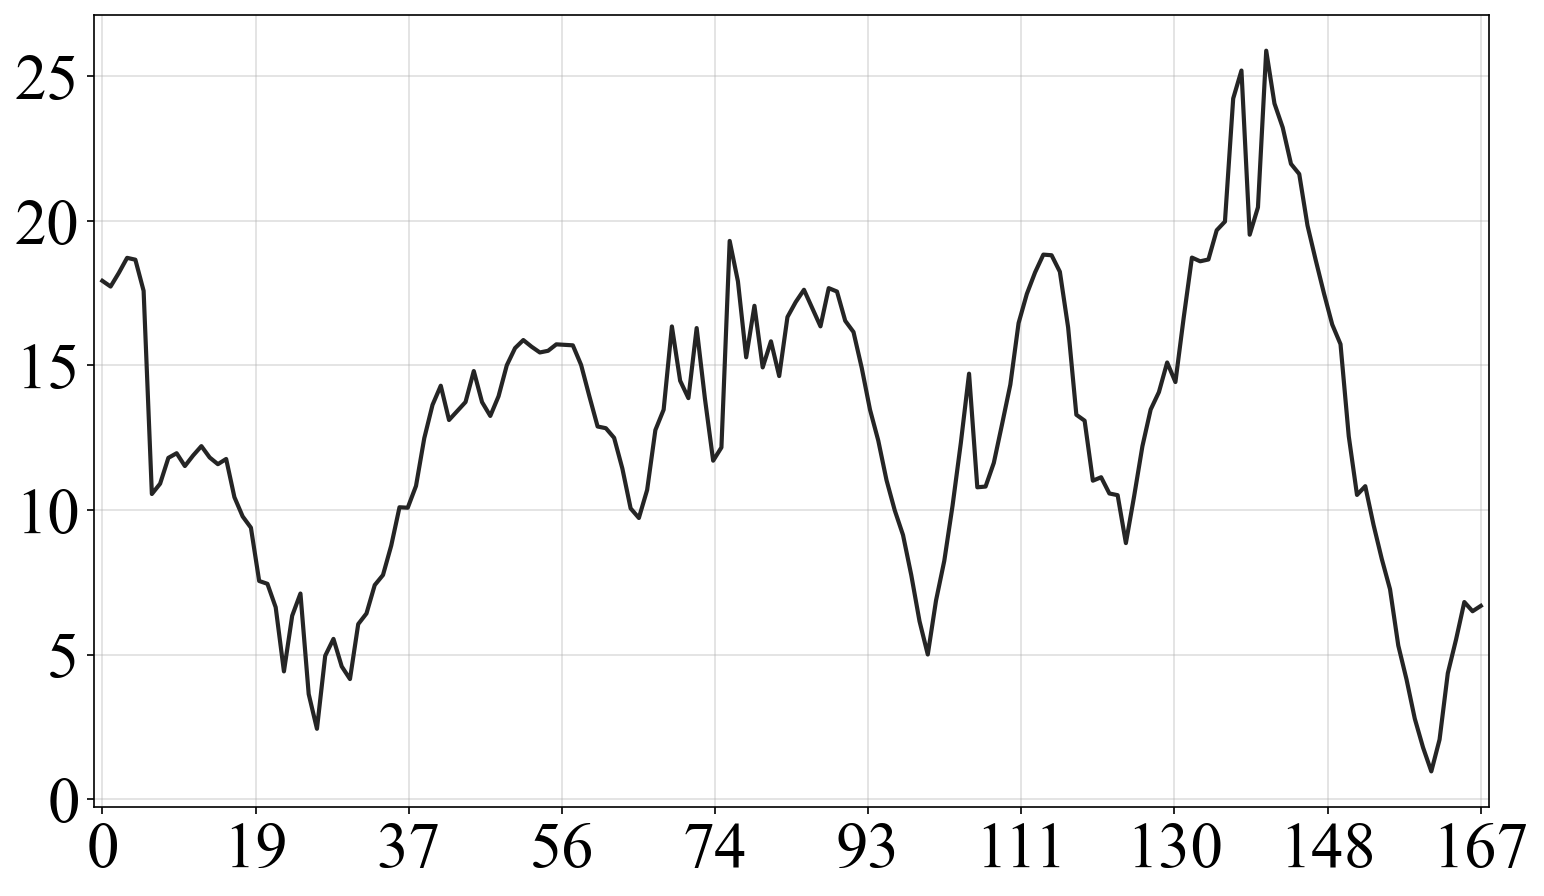

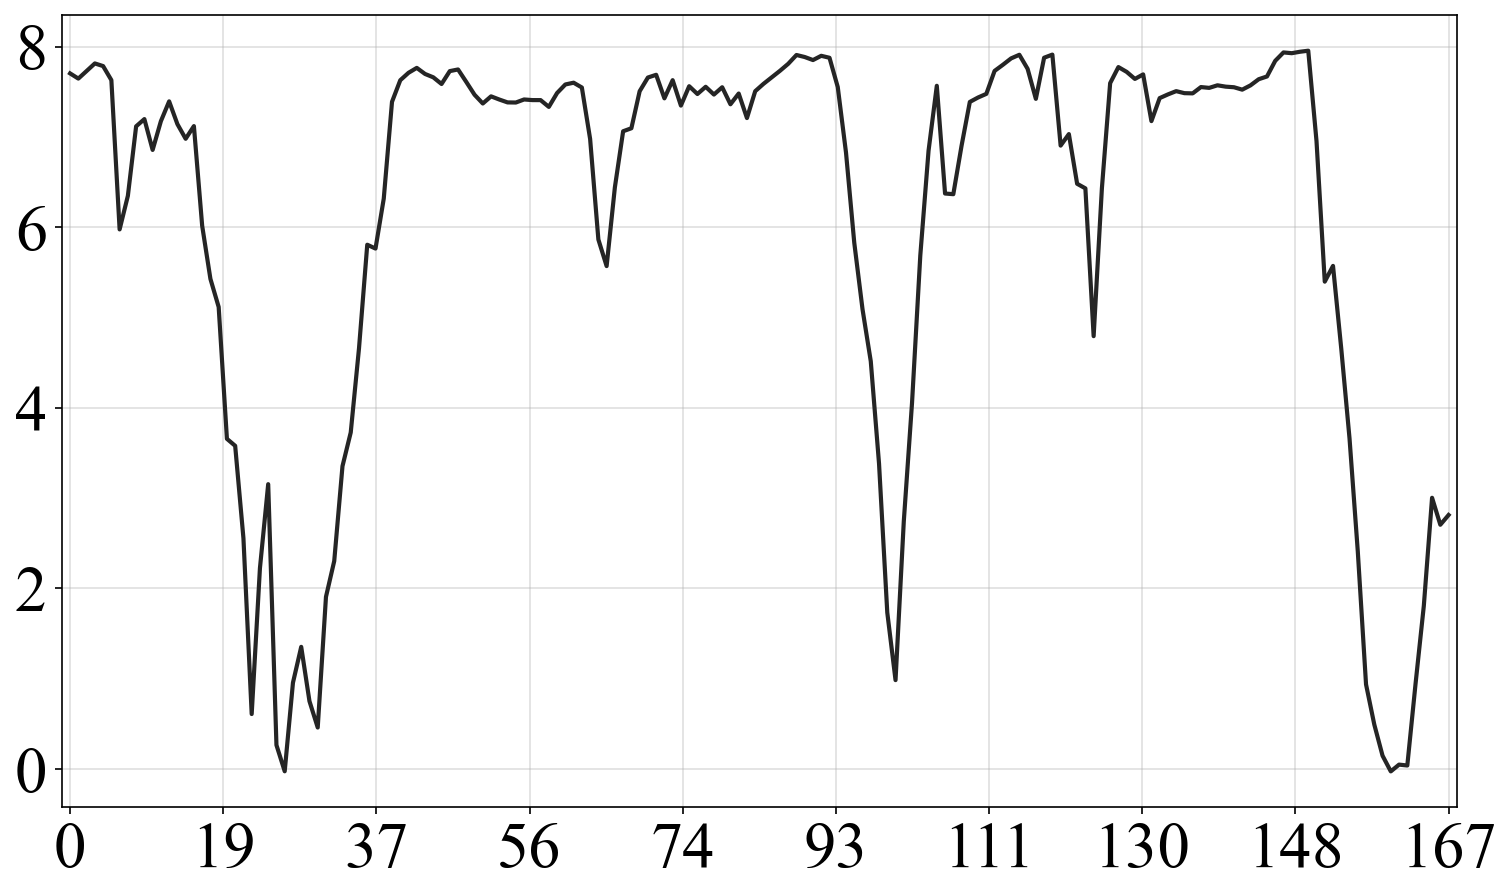

In [11]:
simple_plotter(df.index,[df['S_w [m/s]']])
simple_plotter(df.index,[df['P_WT [MW]']])


In [12]:
WT_farm_scalling = np.ceil(10/3.5) * 5 # MW this is to increase the number of wind farm to 100% (now is 35%)
df['P_prod_WT [MW]'] = WT_farm_scalling*df['P_WT [MW]'] 


In [13]:
df.loc[df['P_prod_WT [MW]'] < 0, 'P_prod_WT [MW]'] = 0

In [14]:

max_P_dem_GFA = 3*20; min_P_dem_GFA =0.5*max_P_dem_GFA; mean_P_dem_GFA = 0.6*max_P_dem_GFA; max_Q_dem_GFA = 3*7; min_Q_dem_GFA = 0; mean_Q_dem_GFA = 3*5
max_P_dem_GFB = 9; min_P_dem_GFB = 0.5*max_P_dem_GFB; mean_P_dem_GFB = 0.6*max_P_dem_GFA; max_Q_dem_GFB = 5 ; min_Q_dem_GFB = 0; mean_Q_dem_GFB = 2
max_P_dem_GFC = 3*20; min_P_dem_GFC = 0.5*max_P_dem_GFC; mean_P_dem_GFC = 0.6*max_P_dem_GFA; max_Q_dem_GFC = 2*7; min_Q_dem_GFC = 0; mean_Q_dem_GFC = 2*5




target_std = 1e-10

num_points = 24 * 7
noise_mean = 0
noise_std = 2
time_intervals = np.linspace(0, num_points, num_points, endpoint=False)
period = 24


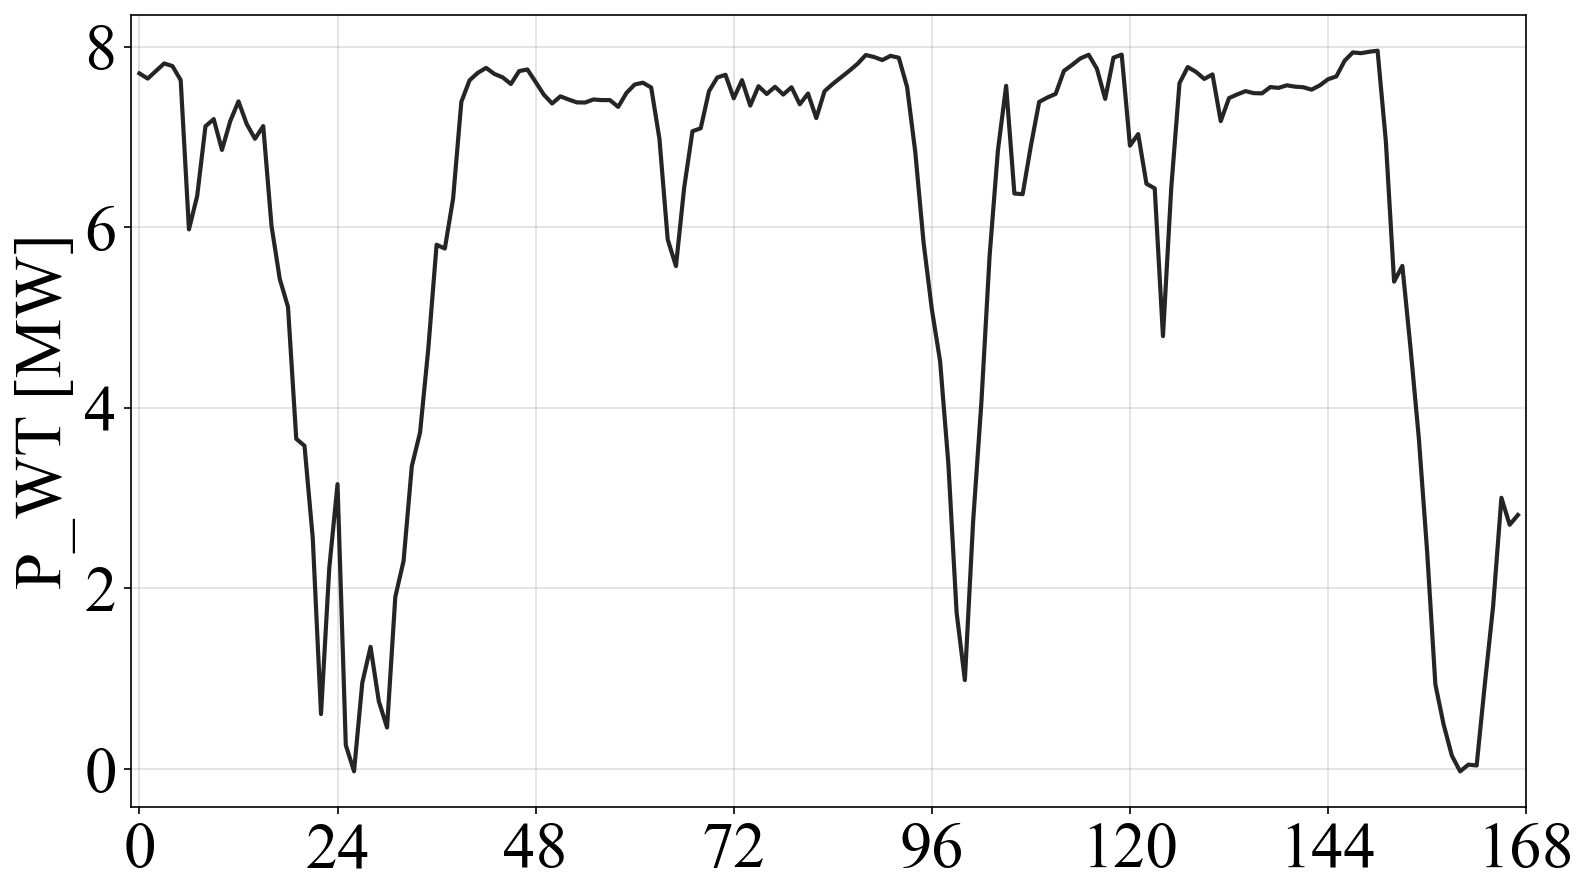

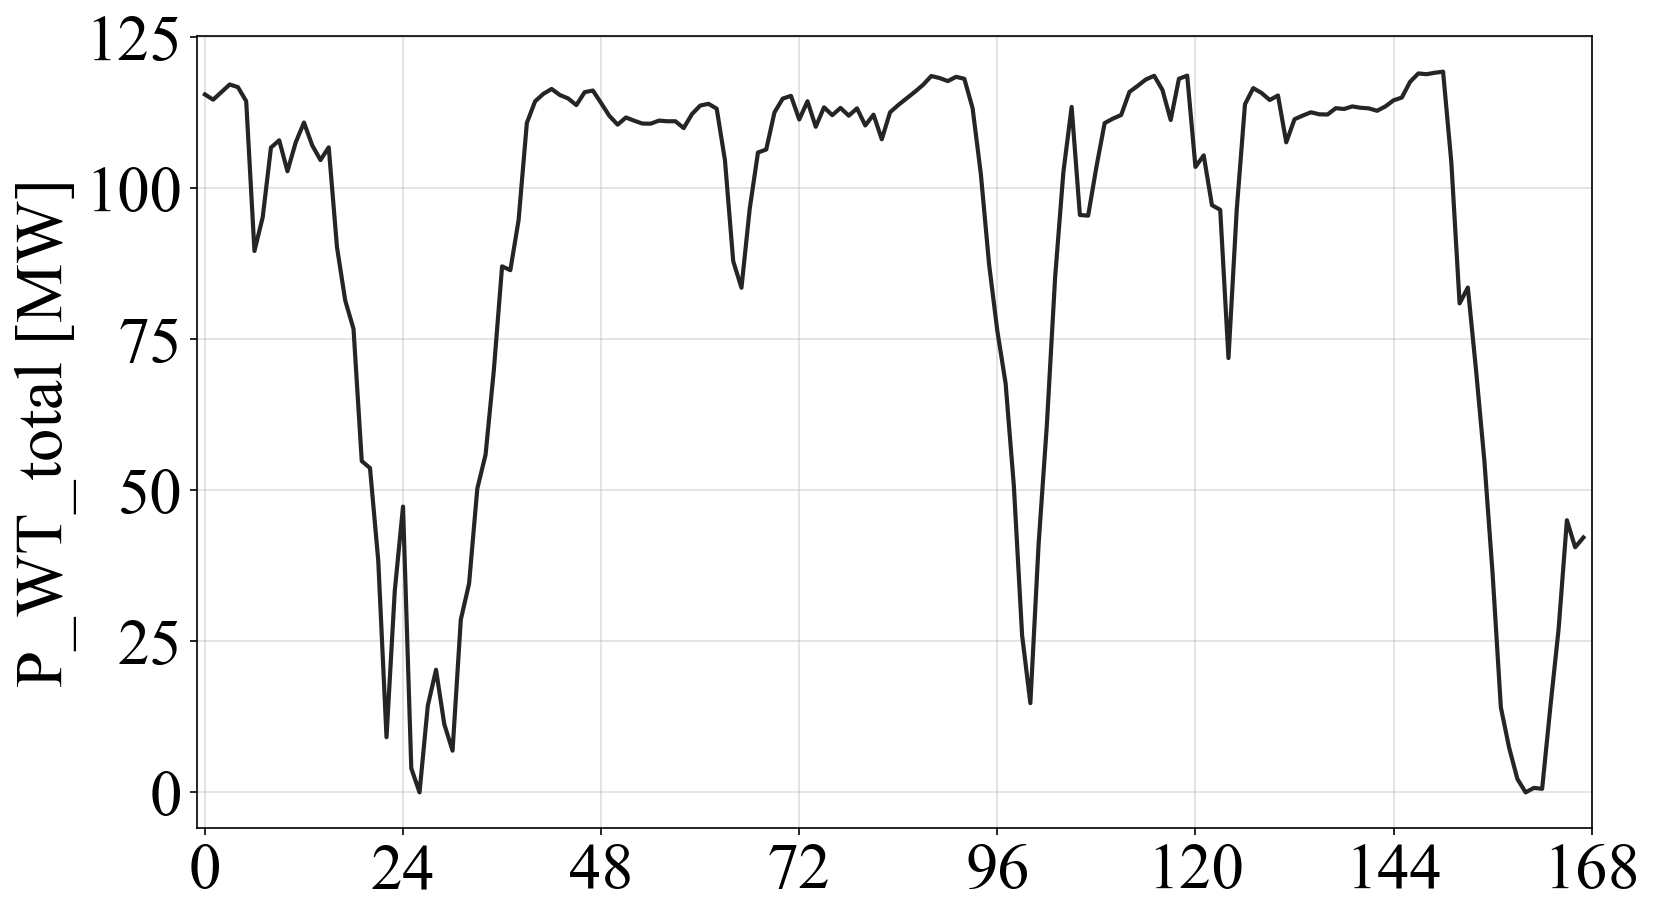

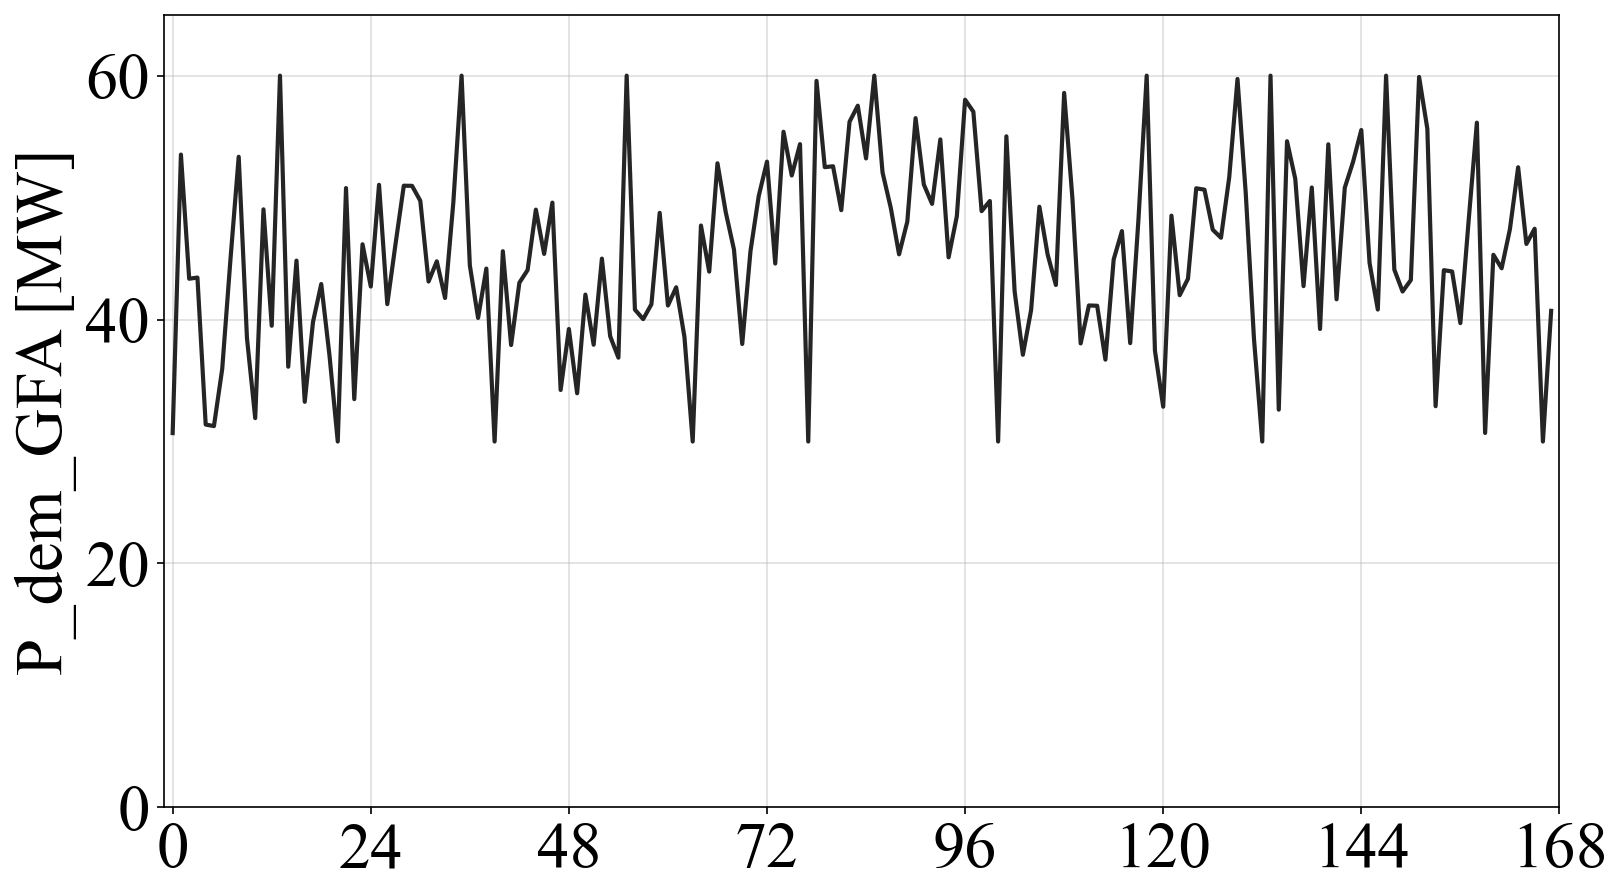

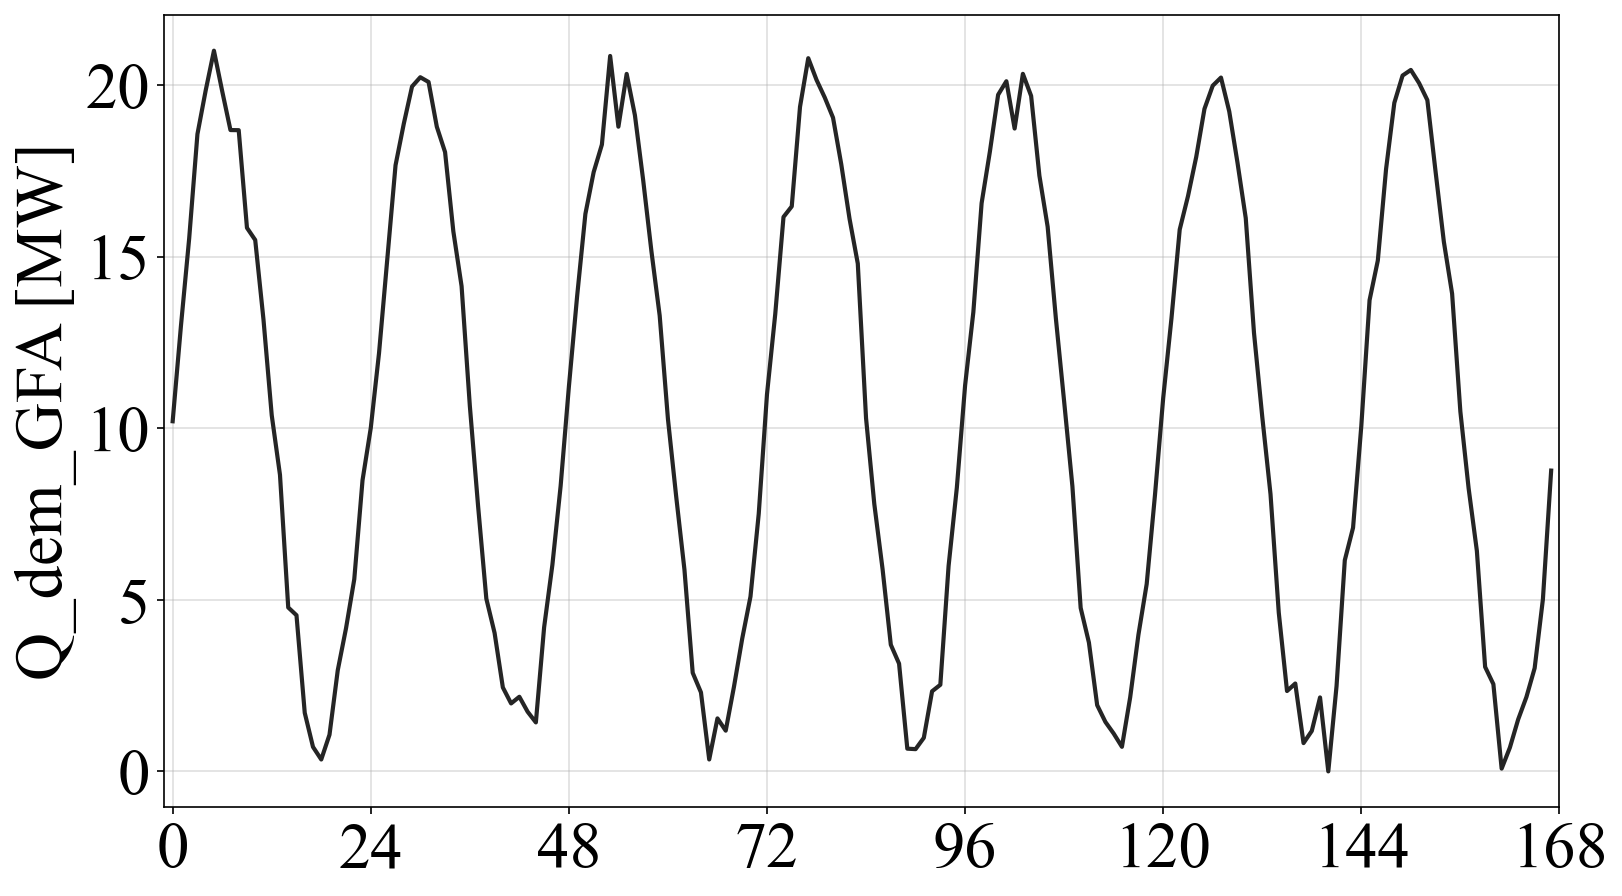

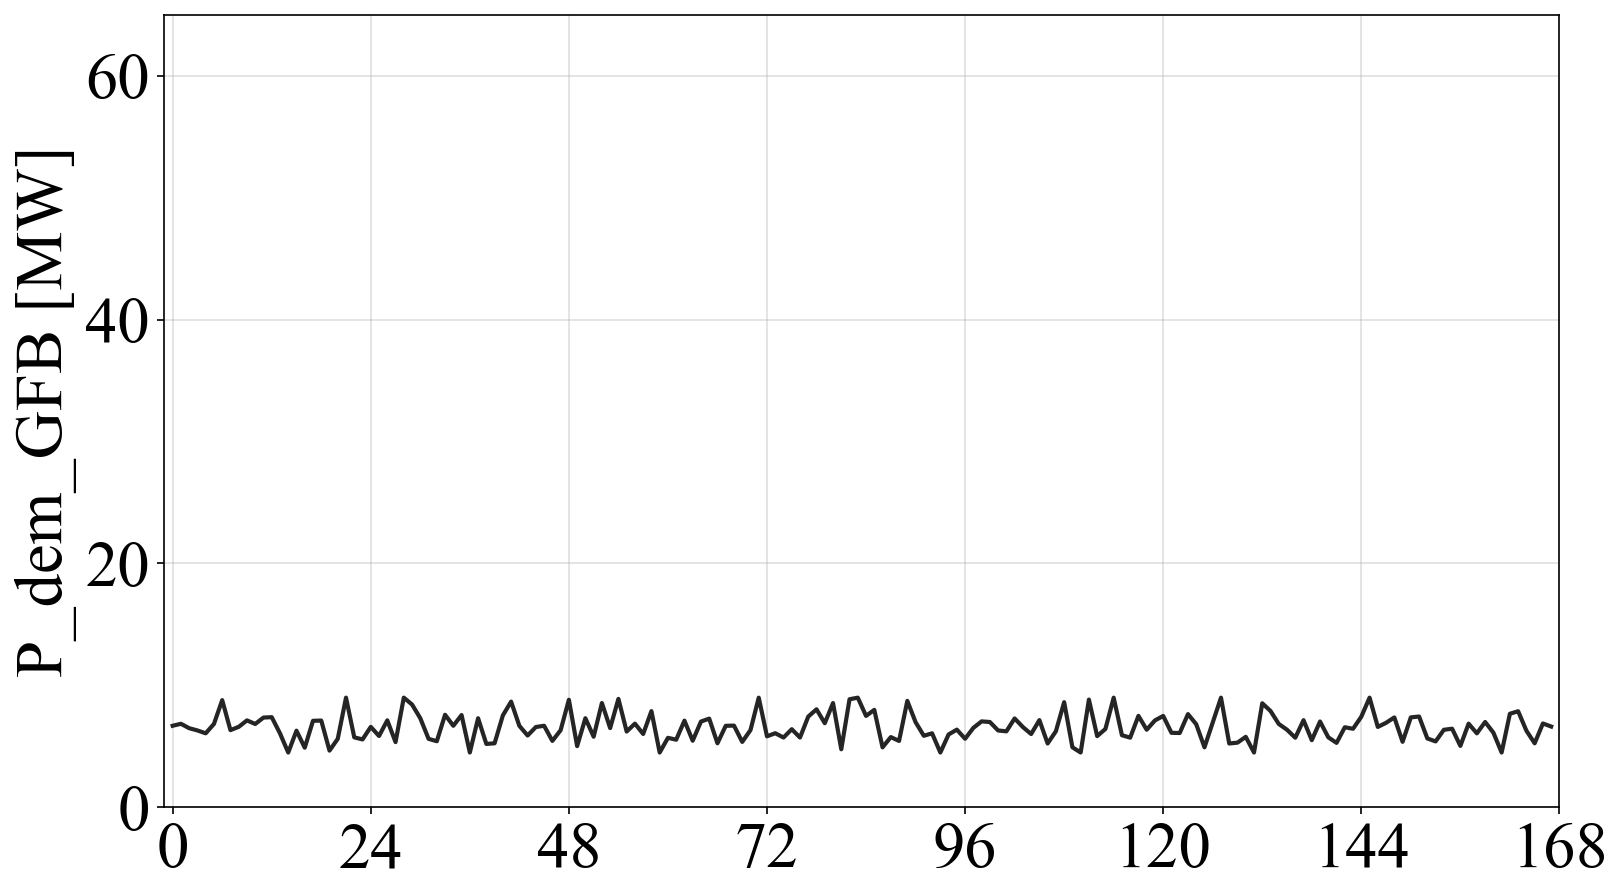

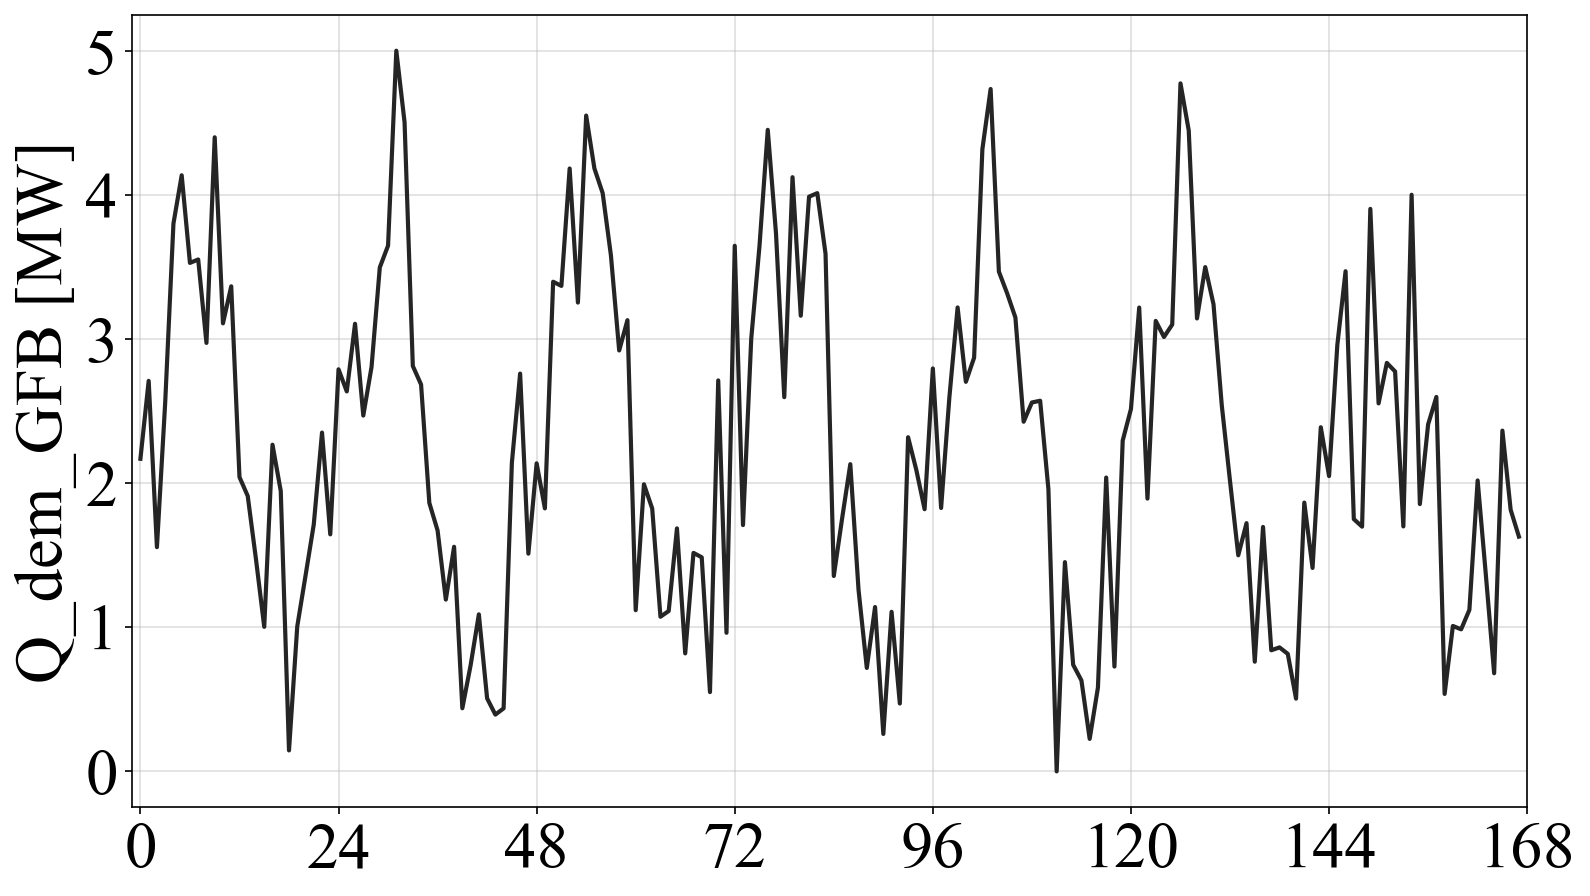

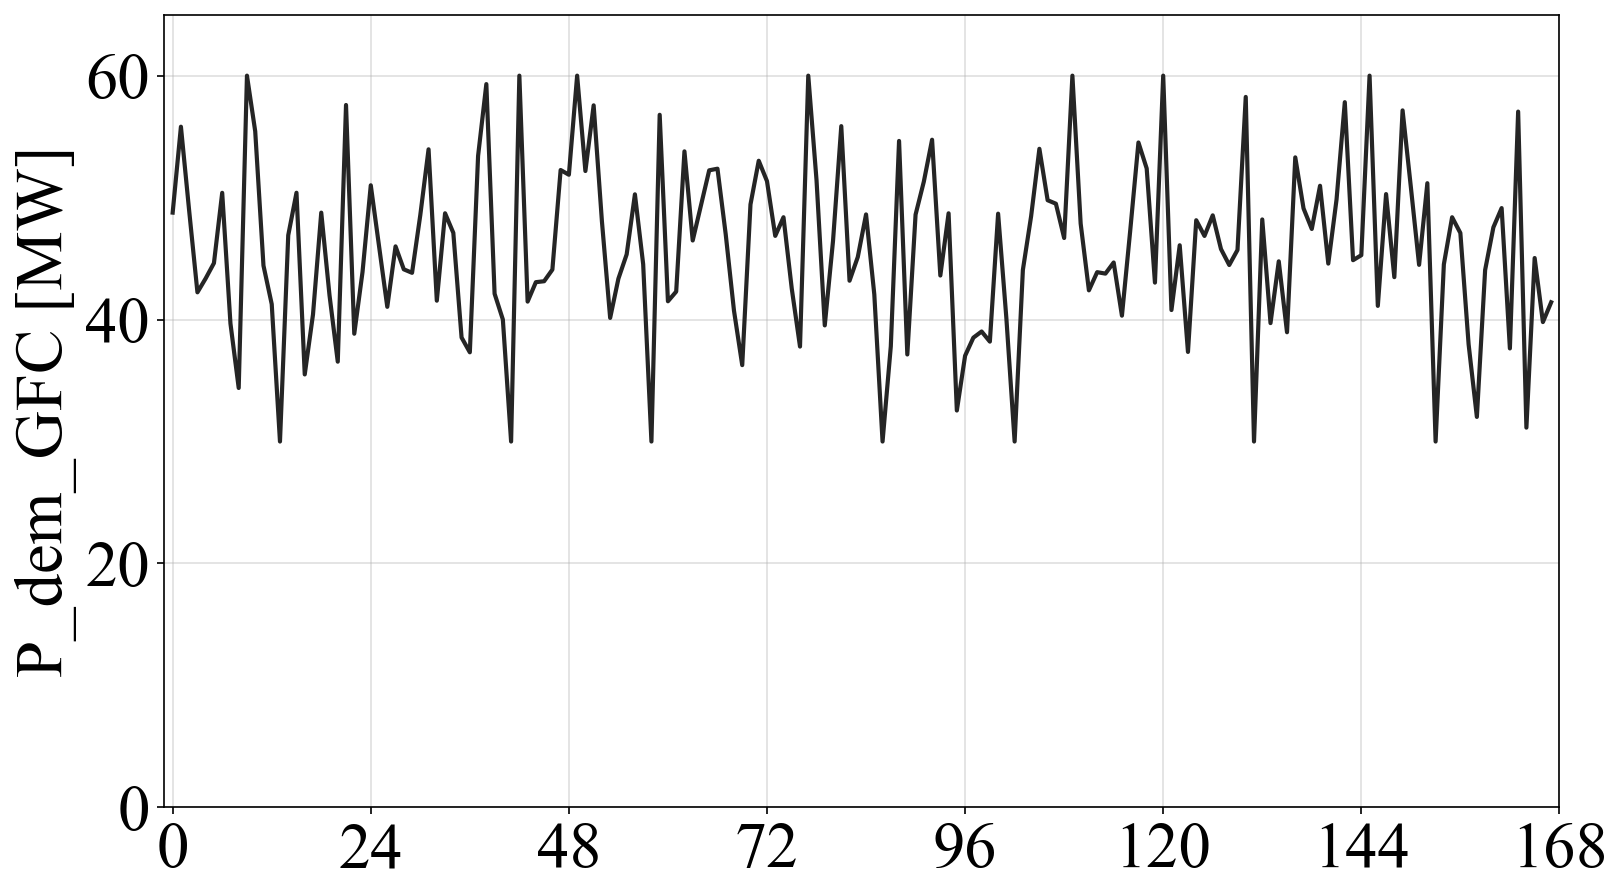

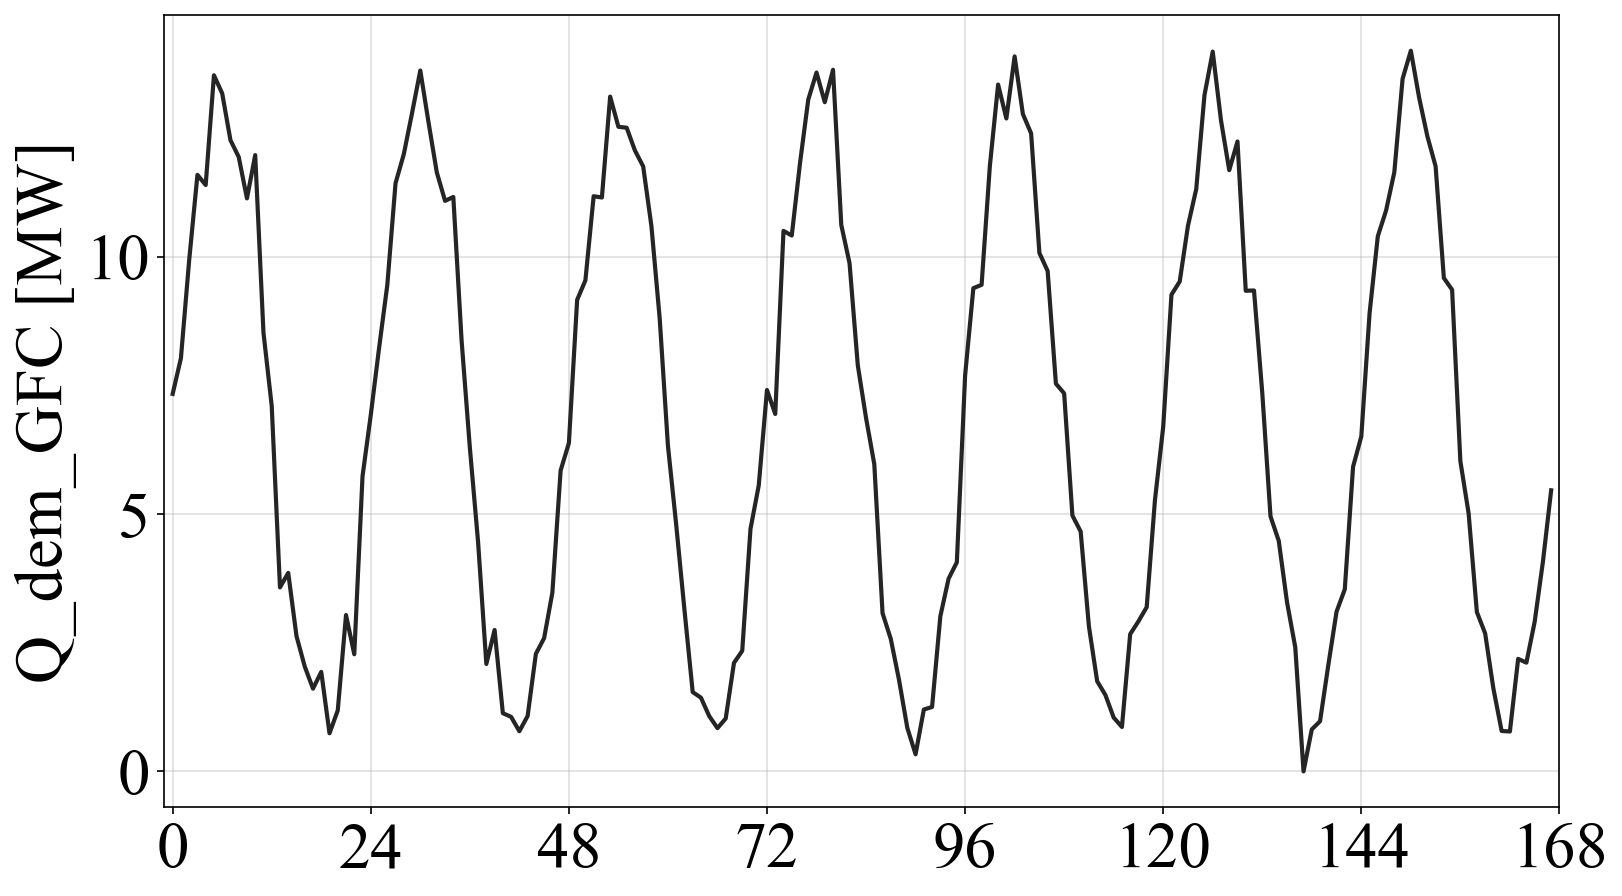

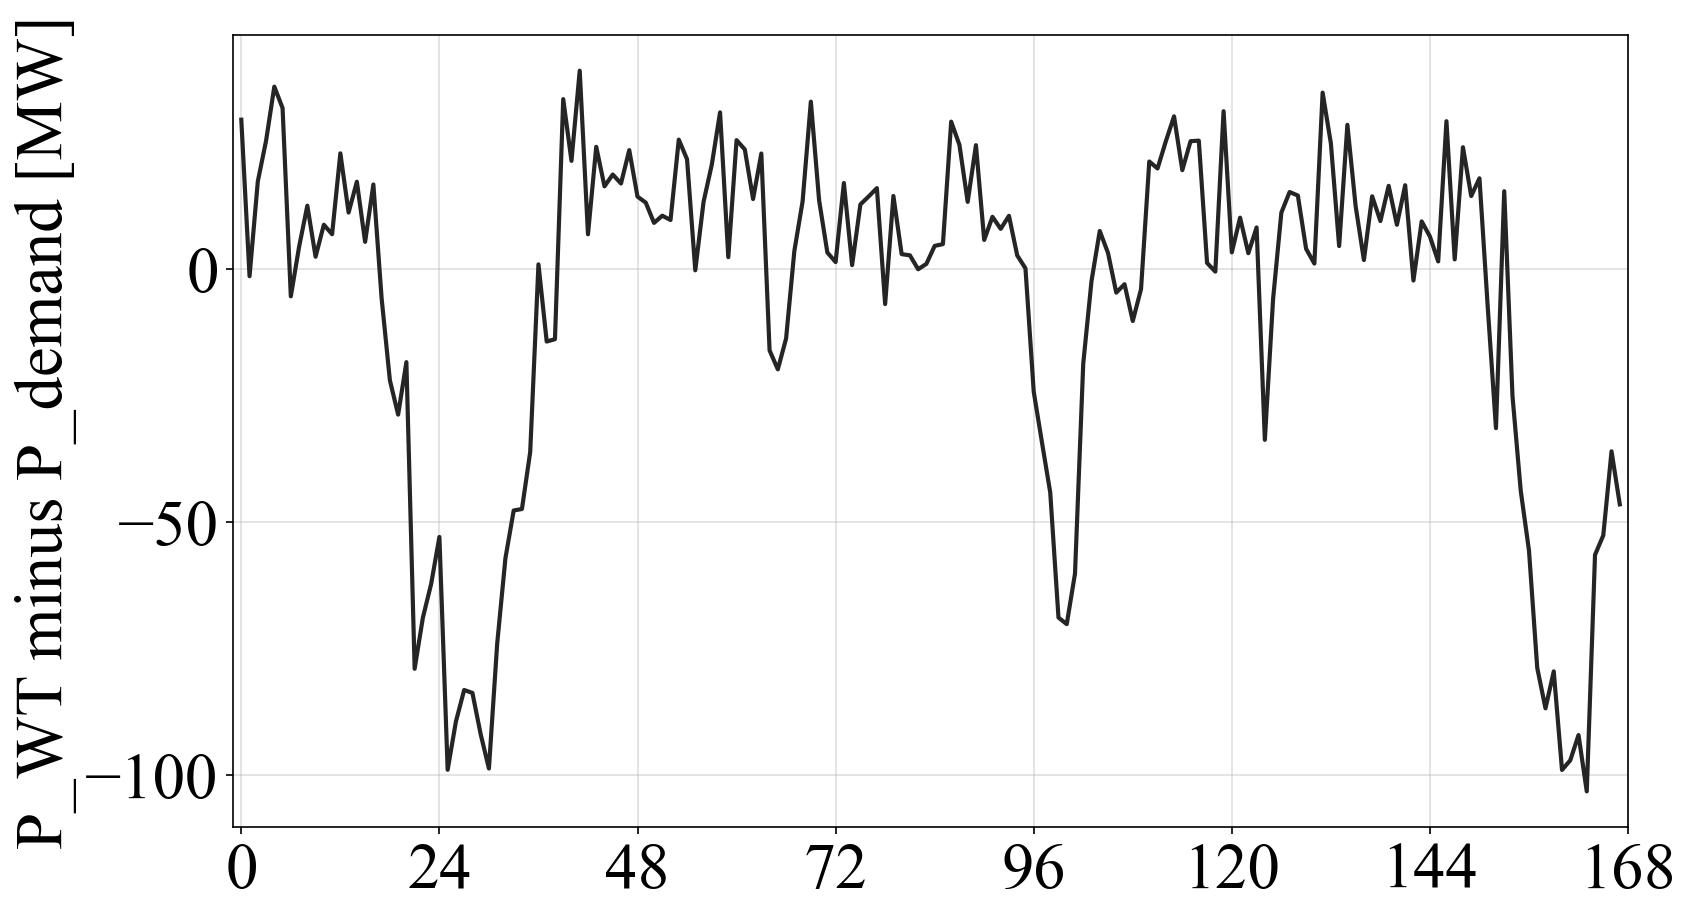

In [15]:
np.random.seed(1234)

power_limit = [0,max_P_dem_GFA+5]



x_show=np.linspace(0,24*7,num=8)
P_coeff = 0.01

week_data = df.copy()
#         week_data = pd.read_excel(data_path,sheet_name=sheet_name)
week_data['P_dem_GFA [MW]'] = np.zeros(len(week_data))
week_data['Q_dem_GFA [MW]'] = np.zeros(len(week_data))
week_data['P_dem_GFB [MW]'] = np.zeros(len(week_data))
week_data['Q_dem_GFB [MW]'] = np.zeros(len(week_data))
week_data['P_dem_GFC [MW]'] = np.zeros(len(week_data))
week_data['Q_dem_GFC [MW]'] = np.zeros(len(week_data))        


#         week_data['P_prod_WT [MW]'] = max_WT * week_data['P_prod_WT [kW]']/ week_data['P_prod_WT [kW]'].max()
simple_plotter(week_data.index,[week_data['P_WT [MW]']],y_label='P_WT [MW]',x_show=x_show)
simple_plotter(week_data.index,[week_data['P_prod_WT [MW]']],y_label='P_WT_total [MW]',x_show=x_show)

for day in range(7):
    str_row = day*24
    end_row = (day+1)*24
    P_dem_GFA_sine_wave = mean_P_dem_GFA/P_coeff * np.sin(2 * np.pi * 24 / period + np.random.uniform(0, 0.1 * np.pi))
    P_dem_GFA_arr = (P_dem_GFA_sine_wave + mean_P_dem_GFA/P_coeff + min_P_dem_GFA)
    P_dem_GFA_noise = np.random.normal(noise_mean, noise_std, size=24)
    P_dem_GFA_arr = P_dem_GFA_arr + P_dem_GFA_noise
    P_dem_GFA_arr = (max_P_dem_GFA-min_P_dem_GFA) * (P_dem_GFA_arr - np.min(P_dem_GFA_arr)) / (np.max(P_dem_GFA_arr) - np.min(P_dem_GFA_arr)) +min_P_dem_GFA
    week_data['P_dem_GFA [MW]'].iloc[str_row:end_row] = P_dem_GFA_arr

simple_plotter(week_data.index,[week_data['P_dem_GFA [MW]']],y_label='P_dem_GFA [MW]',x_show=x_show,y_lim=power_limit)


Q_dem_GFA_sine_wave = mean_Q_dem_GFA/0.5 * np.sin(2 * np.pi * time_intervals / period)
Q_dem_GFA_arr = (Q_dem_GFA_sine_wave + mean_Q_dem_GFA/0.5 + min_Q_dem_GFA)
Q_dem_GFA_noise = np.random.normal(noise_mean, noise_std, size=num_points)
Q_dem_GFA_arr = Q_dem_GFA_arr + Q_dem_GFA_noise
Q_dem_GFA_arr = (max_Q_dem_GFA-min_Q_dem_GFA) * (Q_dem_GFA_arr - np.min(Q_dem_GFA_arr)) / (np.max(Q_dem_GFA_arr) - np.min(Q_dem_GFA_arr))
week_data['Q_dem_GFA [MW]'] = Q_dem_GFA_arr
simple_plotter(week_data.index,[week_data['Q_dem_GFA [MW]']],y_label='Q_dem_GFA [MW]',x_show=x_show)


for day in range(7):
    str_row = day*24
    end_row = (day+1)*24
    P_dem_GFB_sine_wave = mean_P_dem_GFB/P_coeff * np.sin(2 * np.pi * 24 / period + np.random.uniform(0, 0.1 * np.pi))
    P_dem_GFB_arr = (P_dem_GFB_sine_wave + mean_P_dem_GFB/P_coeff + min_P_dem_GFB)
    P_dem_GFB_noise = np.random.normal(noise_mean, noise_std, size=24)
    P_dem_GFB_arr = P_dem_GFB_arr + P_dem_GFB_noise
    P_dem_GFB_arr = (max_P_dem_GFB-min_P_dem_GFB) * (P_dem_GFB_arr - np.min(P_dem_GFB_arr)) / (np.max(P_dem_GFB_arr) - np.min(P_dem_GFB_arr)) +min_P_dem_GFB
    week_data['P_dem_GFB [MW]'].iloc[str_row:end_row] = P_dem_GFB_arr
simple_plotter(week_data.index,[week_data['P_dem_GFB [MW]']],y_label='P_dem_GFB [MW]',x_show=x_show,y_lim=power_limit)

Q_dem_GFB_sine_wave = mean_Q_dem_GFB/0.5 * np.sin(2 * np.pi * time_intervals / period)
Q_dem_GFB_arr = (Q_dem_GFB_sine_wave + mean_Q_dem_GFB/0.5 + min_Q_dem_GFB)
Q_dem_GFB_noise = np.random.normal(noise_mean, noise_std, size=num_points)
Q_dem_GFB_arr = Q_dem_GFB_arr + Q_dem_GFB_noise
Q_dem_GFB_arr = (max_Q_dem_GFB-min_Q_dem_GFB) * (Q_dem_GFB_arr - np.min(Q_dem_GFB_arr)) / (np.max(Q_dem_GFB_arr) - np.min(Q_dem_GFB_arr)) +min_Q_dem_GFB
week_data['Q_dem_GFB [MW]'] = Q_dem_GFB_arr
simple_plotter(week_data.index,[week_data['Q_dem_GFB [MW]']],y_label='Q_dem_GFB [MW]',x_show=x_show)

for day in range(7):
    str_row = day*24
    end_row = (day+1)*24
    P_dem_GFC_sine_wave = mean_P_dem_GFC/P_coeff * np.sin(2 * np.pi * 24 / period + np.random.uniform(0, 0.1 * np.pi))
    P_dem_GFC_arr = (P_dem_GFC_sine_wave + mean_P_dem_GFC/P_coeff + min_P_dem_GFC)
    P_dem_GFC_noise = np.random.normal(noise_mean, noise_std, size=24)
    P_dem_GFC_arr = P_dem_GFC_arr + P_dem_GFC_noise
    P_dem_GFC_arr = (max_P_dem_GFC-min_P_dem_GFC) * (P_dem_GFC_arr - np.min(P_dem_GFC_arr)) / (np.max(P_dem_GFC_arr) - np.min(P_dem_GFC_arr)) +min_P_dem_GFC
    week_data['P_dem_GFC [MW]'].iloc[str_row:end_row] = P_dem_GFC_arr
simple_plotter(week_data.index,[week_data['P_dem_GFC [MW]']],y_label='P_dem_GFC [MW]',x_show=x_show,y_lim=power_limit)

Q_dem_GFC_sine_wave = mean_Q_dem_GFC/0.5 * np.sin(2 * np.pi * time_intervals / period)
Q_dem_GFC_arr = (Q_dem_GFC_sine_wave + mean_Q_dem_GFC/0.5 + min_Q_dem_GFC)
Q_dem_GFC_noise = np.random.normal(noise_mean, noise_std, size=num_points)
Q_dem_GFC_arr = Q_dem_GFC_arr + Q_dem_GFC_noise
Q_dem_GFC_arr = max_Q_dem_GFC * (Q_dem_GFC_arr - np.min(Q_dem_GFC_arr)) / (np.max(Q_dem_GFC_arr) - np.min(Q_dem_GFC_arr))
week_data['Q_dem_GFC [MW]'] = Q_dem_GFC_arr
simple_plotter(week_data.index,[week_data['Q_dem_GFC [MW]']],y_label='Q_dem_GFC [MW]',x_show=x_show)

# week_data[['El_Price_buy [EUR/MJ]','El_Price_sell [EUR/MJ]','NG_Price [EUR/MJ]','El_Price_diff [EUR/MJ]','El_Price_NG_Price_diff [EUR/MJ]']] = 1000*week_data[['El_Price_buy [EUR/kJ]','El_Price_sell [EUR/kJ]','NG_Price [EUR/kJ]','El_Price_diff [EUR/kJ]','El_Price_NG_Price_diff [EUR/kJ]']]

# week_data = week_data.drop(columns=['Unnamed: 0', 'P_dem [kW]', 'Q_dem [kW]','P_WT [kW]','P_dem_minus_P_WT [kW]', 'P_dem_Q_dem_minus_P_prod_WT [kW]','El_Price_buy [EUR/kJ]','El_Price_sell [EUR/kJ]','NG_Price [EUR/kJ]','El_Price_diff [EUR/kJ]','El_Price_NG_Price_diff [EUR/kJ]'])

# save_df_excel_to_path(week_data, 'Integrated Data', sheet_name, path_saving_data_results)


simple_plotter(week_data.index,[week_data['P_prod_WT [MW]']-(week_data['P_dem_GFA [MW]']+week_data['P_dem_GFB [MW]']+week_data['P_dem_GFC [MW]'])],y_label='P_WT minus P_demand [MW]',x_show=x_show)




In [16]:
week_data['P_dem_GFA-pred. [MW]'] = week_data['P_dem_GFA [MW]'] + np.random.uniform(-4, 4, size=len(week_data))
week_data['Q_dem_GFA-pred. [MW]'] = week_data['Q_dem_GFA [MW]'] + np.random.uniform(-2, 2, size=len(week_data))
week_data['P_dem_GFB-pred. [MW]'] = week_data['P_dem_GFB [MW]'] + np.random.uniform(-1, 1, size=len(week_data))
week_data['Q_dem_GFB-pred. [MW]'] = week_data['Q_dem_GFB [MW]'] + np.random.uniform(-0.5, 0.5, size=len(week_data))
week_data['P_dem_GFC-pred. [MW]'] = week_data['P_dem_GFC [MW]'] + np.random.uniform(-4, 4, size=len(week_data))
week_data['Q_dem_GFC-pred. [MW]'] = week_data['Q_dem_GFC [MW]'] + np.random.uniform(-1, 1, size=len(week_data))
week_data['P_prod_WT-pred. [MW]'] = week_data['P_prod_WT [MW]'] + np.random.uniform(-4, 4, size=len(week_data))


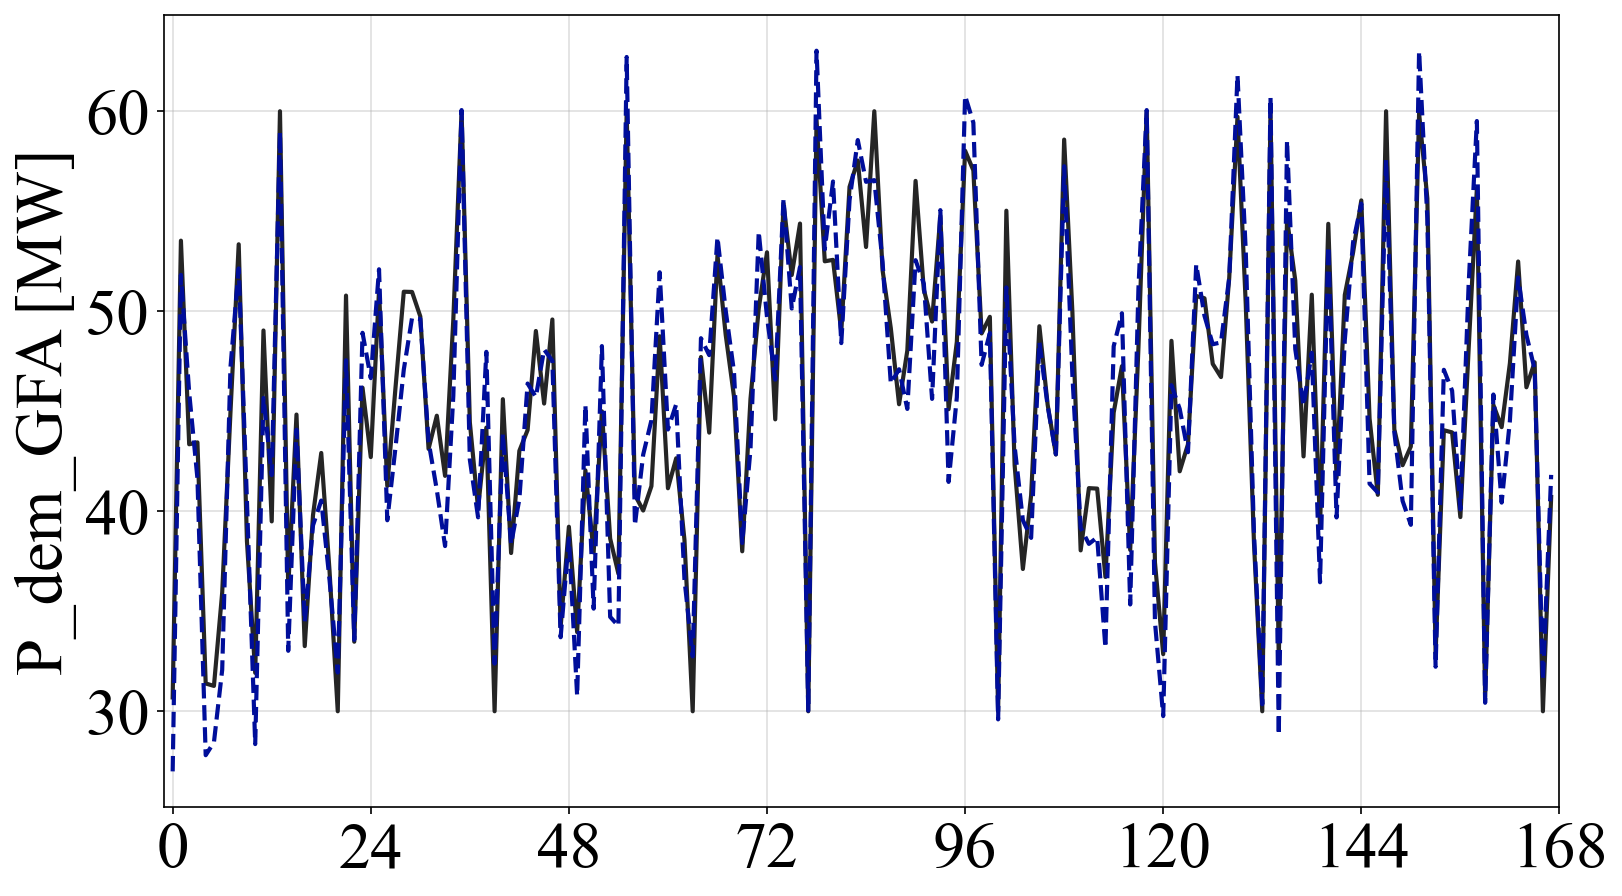

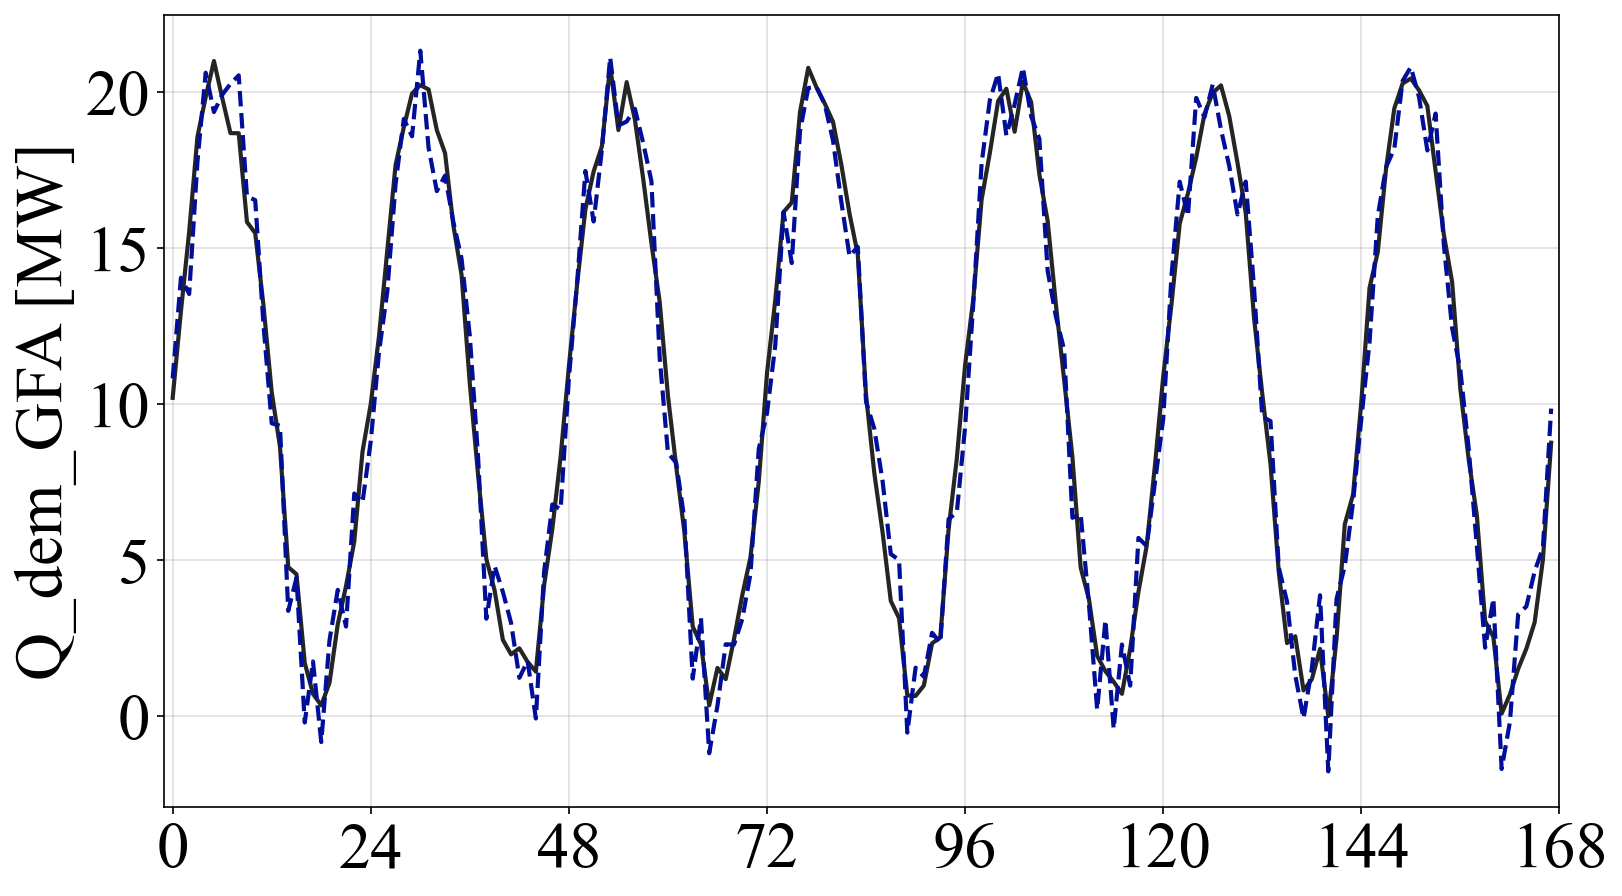

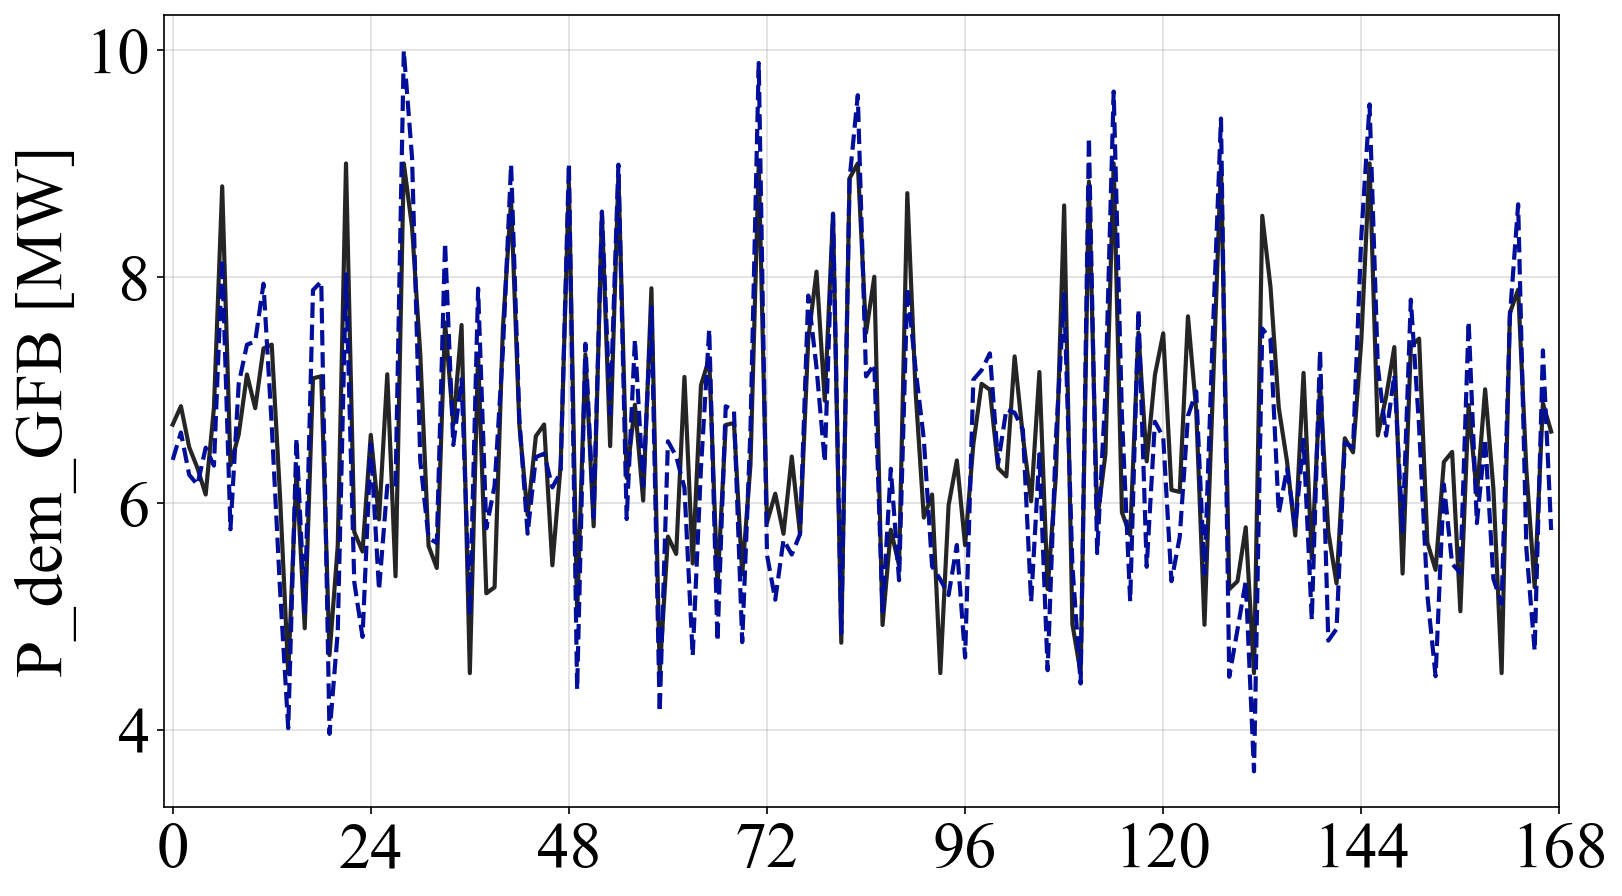

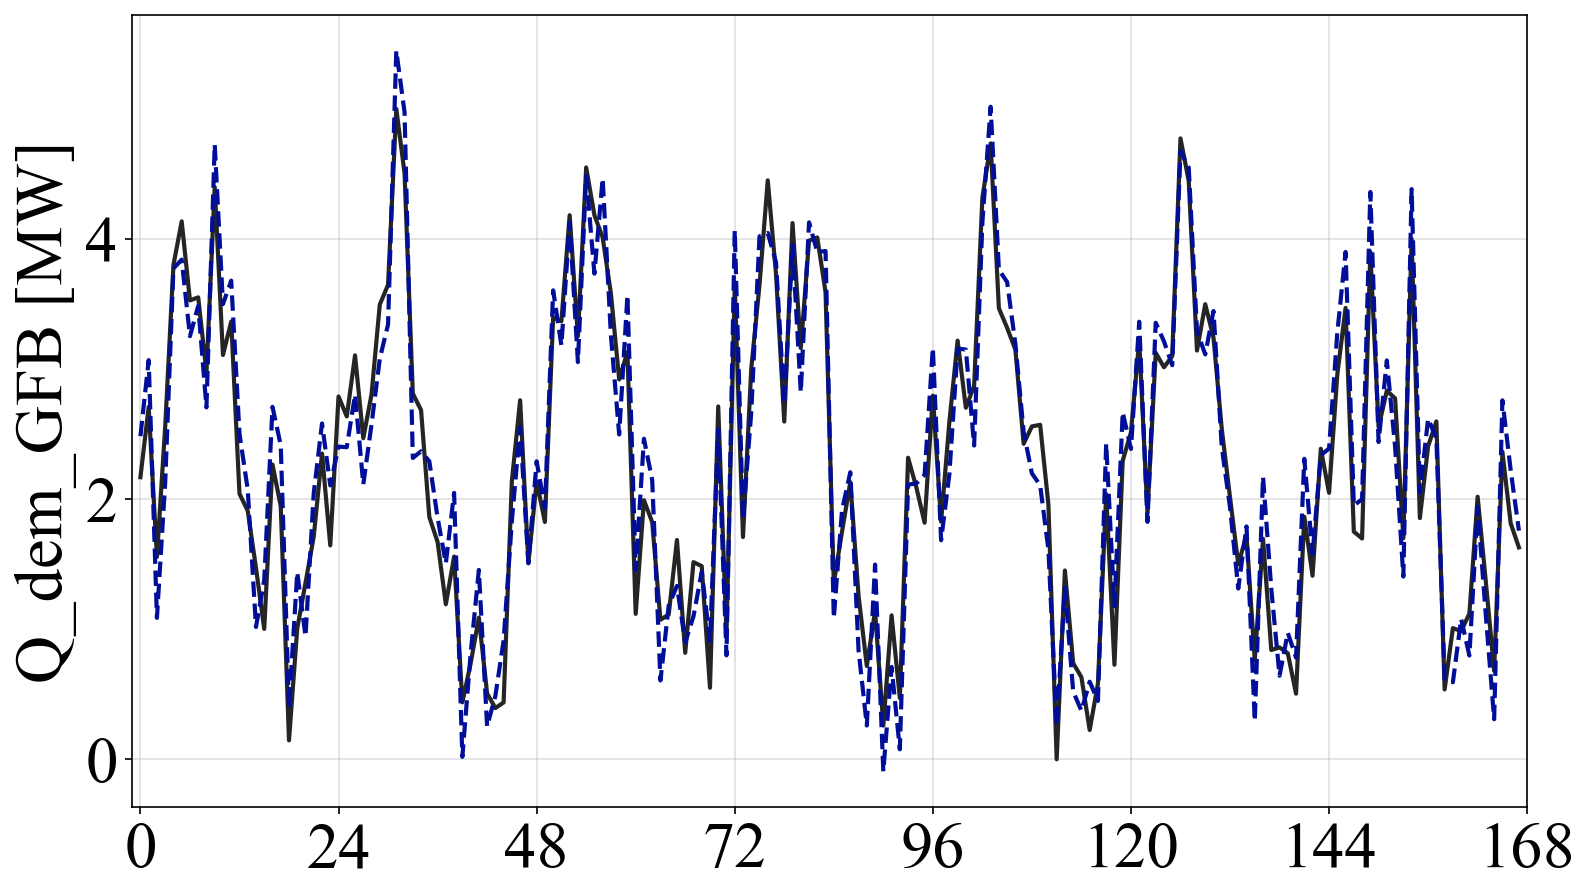

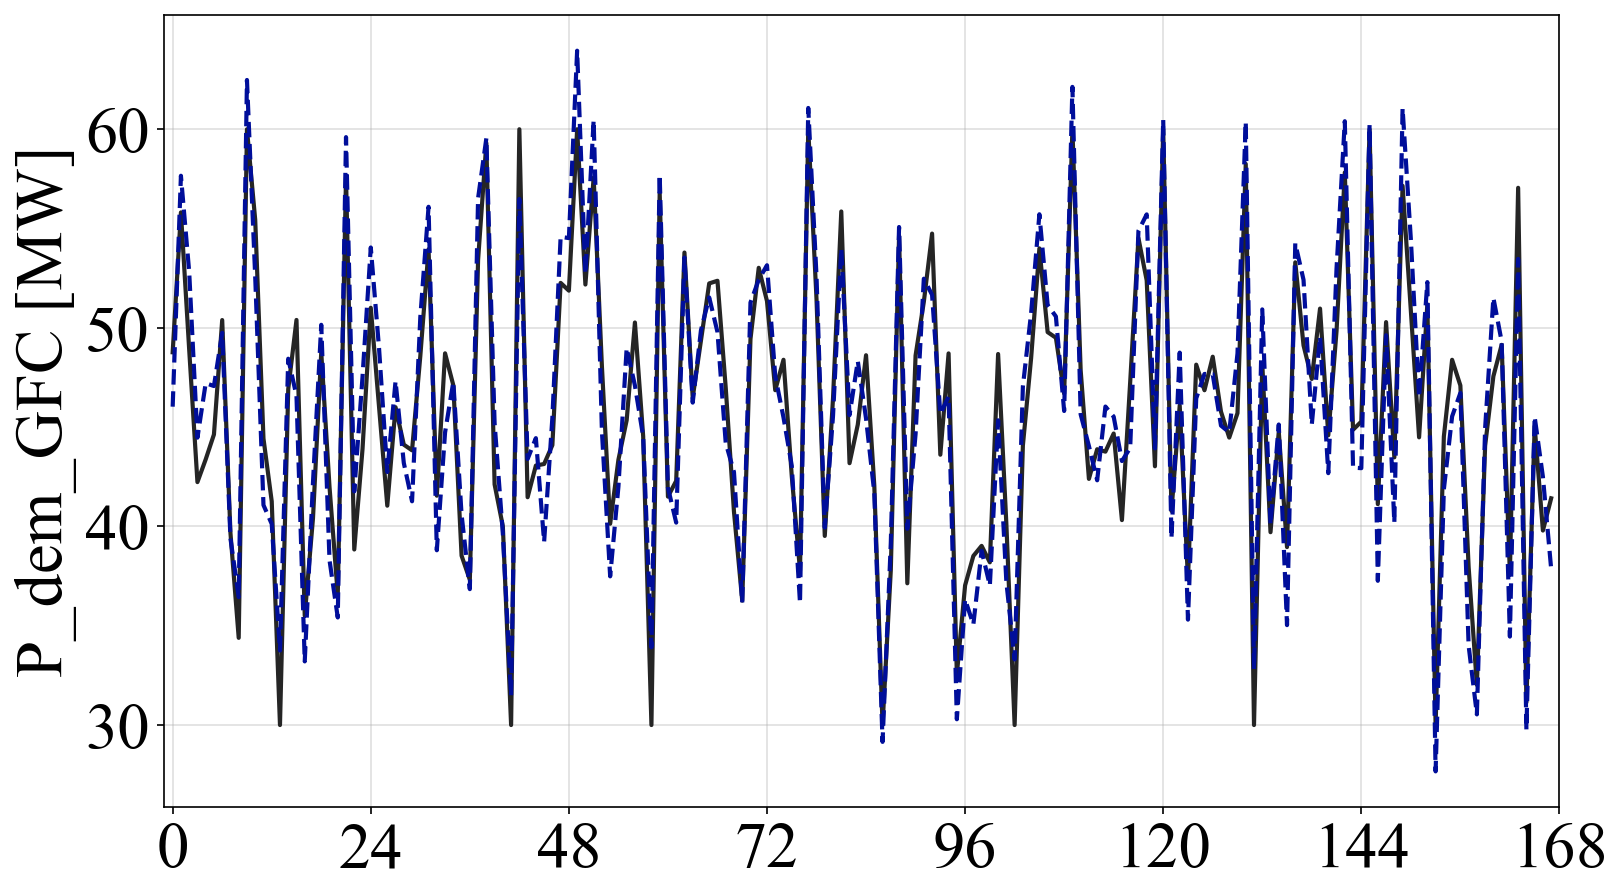

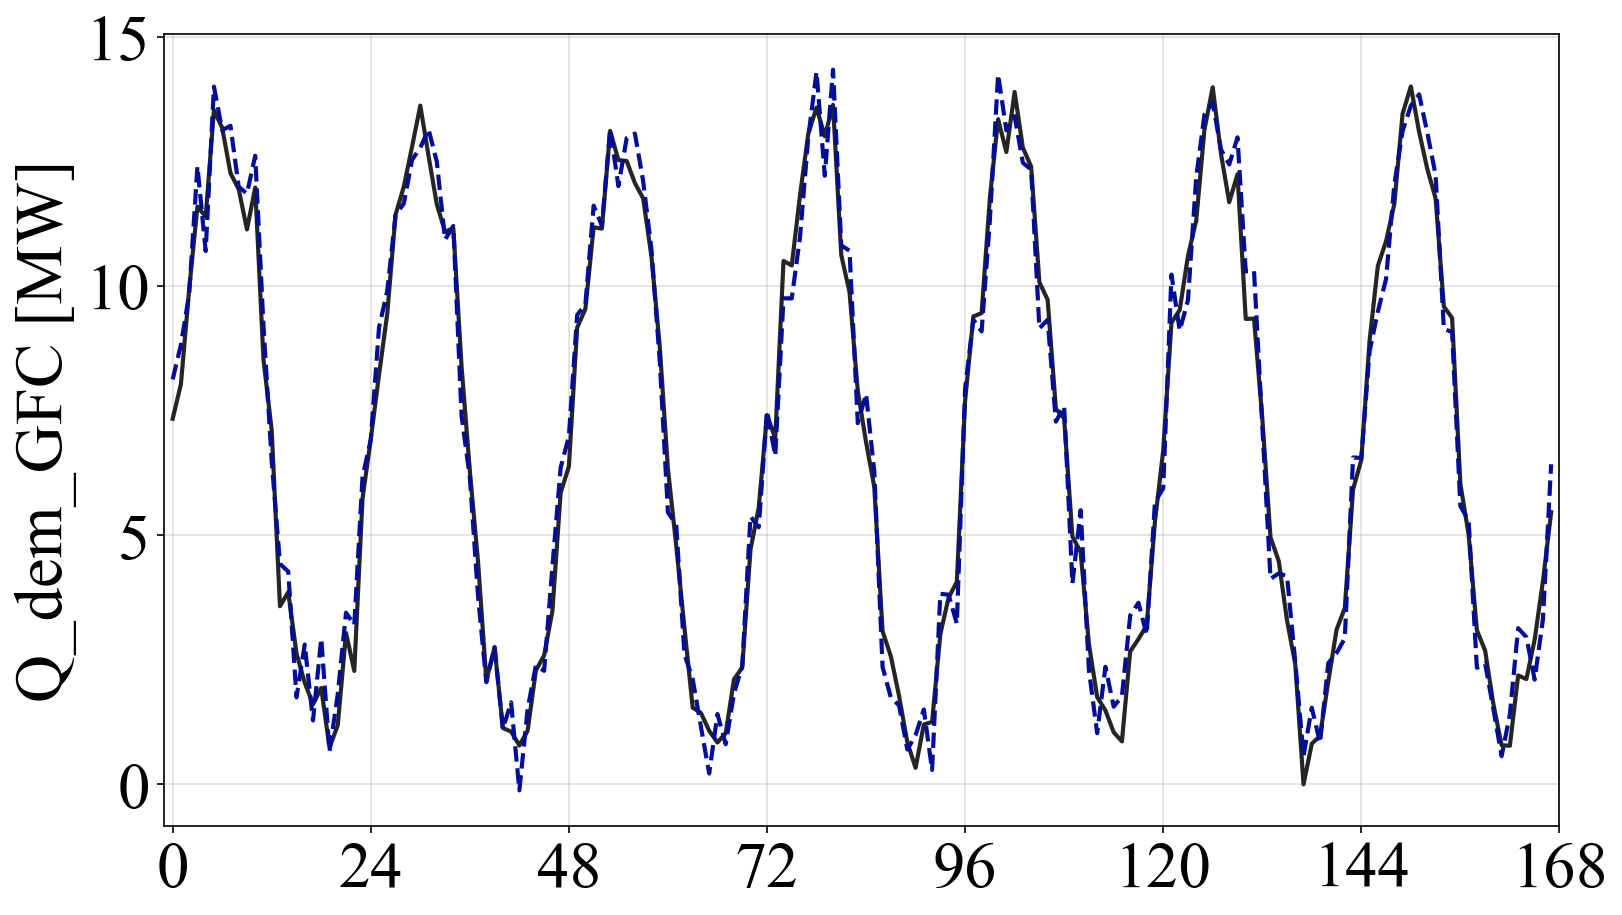

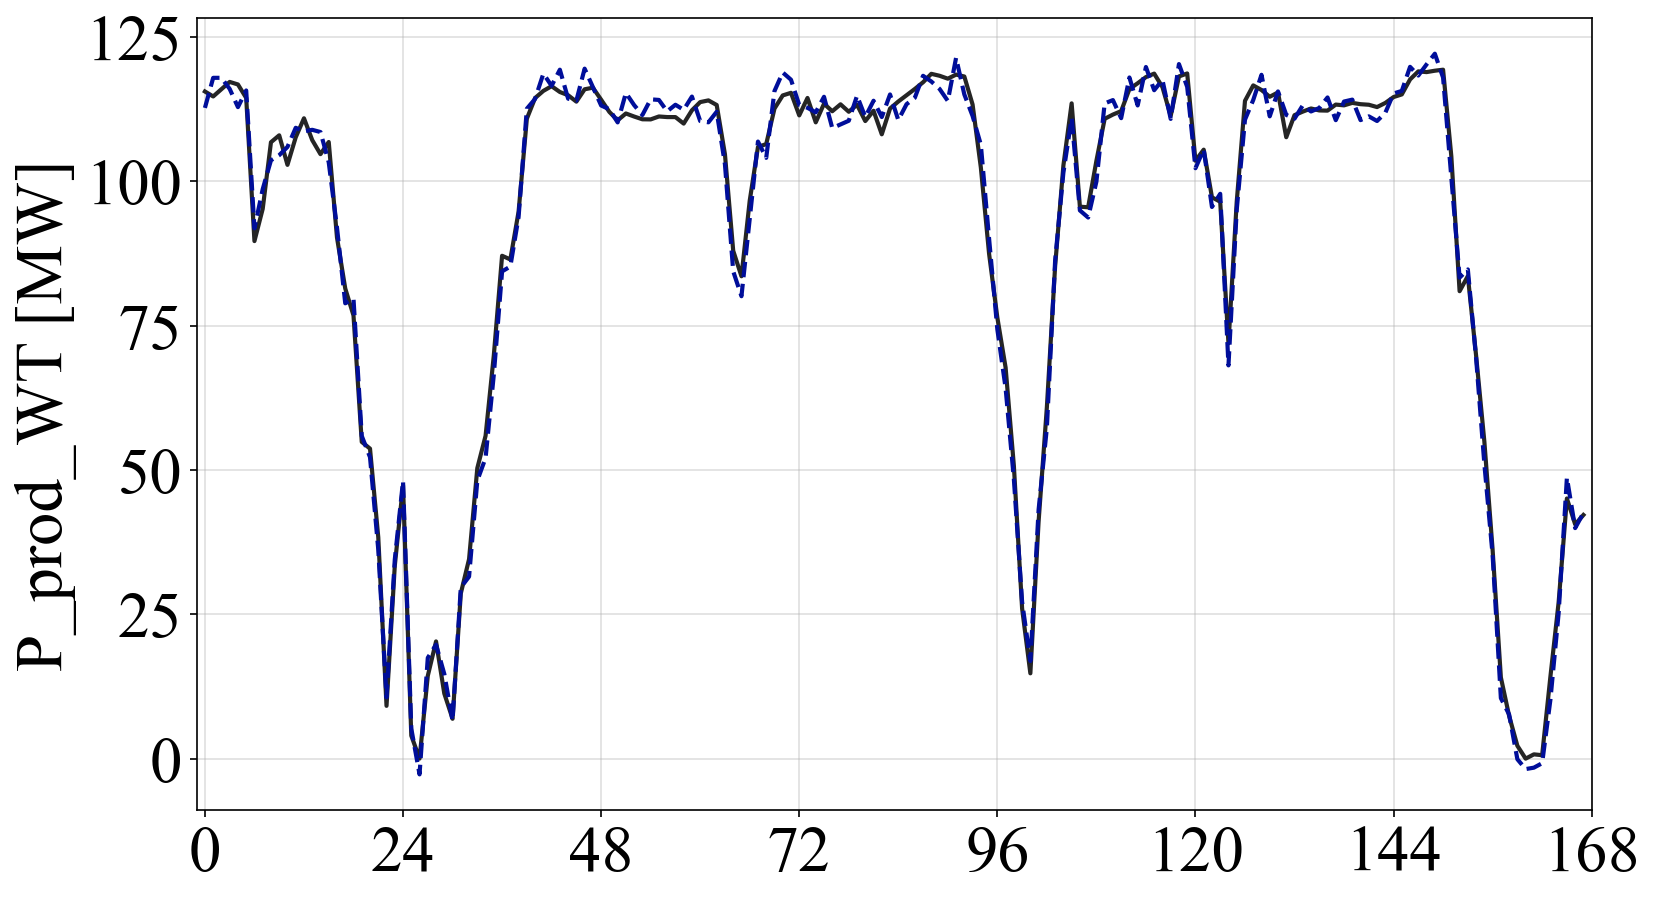

In [17]:
simple_plotter(week_data.index,[week_data['P_dem_GFA [MW]'],week_data['P_dem_GFA-pred. [MW]']],y_label='P_dem_GFA [MW]',x_show=x_show,y_lim=None,dashed=[1])
simple_plotter(week_data.index,[week_data['Q_dem_GFA [MW]'],week_data['Q_dem_GFA-pred. [MW]']],y_label='Q_dem_GFA [MW]',x_show=x_show,y_lim=None,dashed=[1])
simple_plotter(week_data.index,[week_data['P_dem_GFB [MW]'],week_data['P_dem_GFB-pred. [MW]']],y_label='P_dem_GFB [MW]',x_show=x_show,y_lim=None,dashed=[1])
simple_plotter(week_data.index,[week_data['Q_dem_GFB [MW]'],week_data['Q_dem_GFB-pred. [MW]']],y_label='Q_dem_GFB [MW]',x_show=x_show,y_lim=None,dashed=[1])
simple_plotter(week_data.index,[week_data['P_dem_GFC [MW]'],week_data['P_dem_GFC-pred. [MW]']],y_label='P_dem_GFC [MW]',x_show=x_show,y_lim=None,dashed=[1])
simple_plotter(week_data.index,[week_data['Q_dem_GFC [MW]'],week_data['Q_dem_GFC-pred. [MW]']],y_label='Q_dem_GFC [MW]',x_show=x_show,y_lim=None,dashed=[1])
simple_plotter(week_data.index,[week_data['P_prod_WT [MW]'],week_data['P_prod_WT-pred. [MW]']],y_label='P_prod_WT [MW]',x_show=x_show,y_lim=None,dashed=[1])


In [18]:
print((week_data['P_prod_WT [MW]']-(week_data['P_dem_GFA [MW]']+week_data['P_dem_GFB [MW]']+week_data['P_dem_GFC [MW]'])).sum())

print((week_data['P_prod_WT [MW]']).sum())

print(((week_data['P_dem_GFA [MW]']+week_data['P_dem_GFB [MW]']+week_data['P_dem_GFC [MW]'])).sum())
print(((week_data['Q_dem_GFA [MW]']+week_data['Q_dem_GFB [MW]']+week_data['Q_dem_GFC [MW]'])).sum())


-1063.8825236035282
15381.403669461422
16445.286193064952
3324.734717637788


In [22]:
1063.8825236035282*3600/1000 + 3324.734717637788*3600/1000

15799.022068468737

In [4]:
55373-59203

-3830

In [21]:
week_data = pd.concat((data_reserve[['year','month','day','hour','minute','second']],week_data),axis=1)


In [22]:
week_data = week_data.drop(labels='P_WT [MW]',axis=1)

In [23]:
#Save data

save_data_path = '/Users/2923185/Desktop/New NextMGT/Offshore Microgrid/Data'

save_df_excel_to_path(week_data,'integrated_data','week 1', save_data_path)



The data-frame is saved in: /Users/2923185/Desktop/New NextMGT/Offshore Microgrid/Data/integrated_data.xlsx
